<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


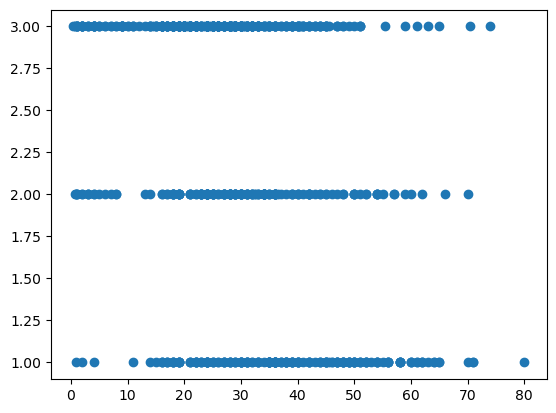

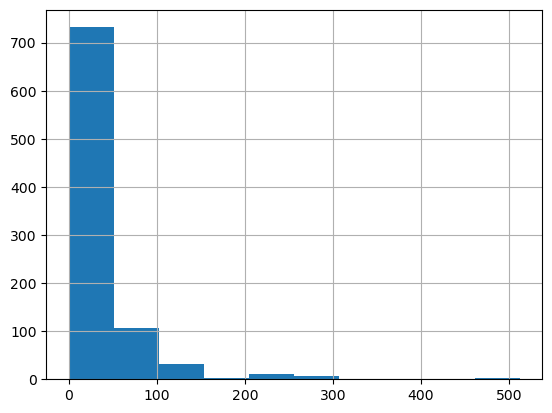

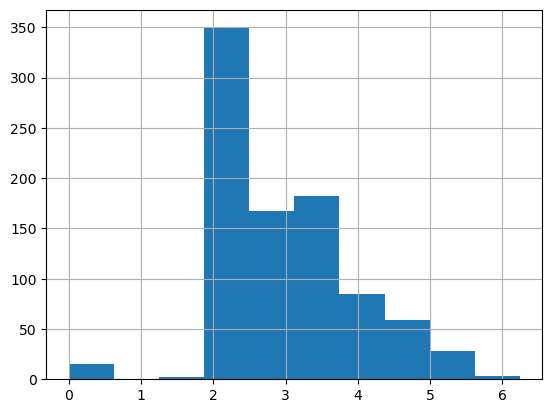

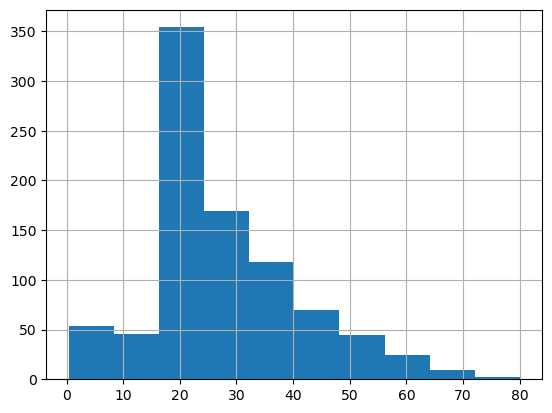

In [1]:
%run ./workbook.ipynb

In [2]:
from torch import tensor
import torch

In [3]:
t_dep = tensor(y)

In [4]:
X.head()

,Age,SibSp,Parch,LogFare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,22.0,1,0,2.110213,0,1,0,0,1,0,0,1
1,38.0,1,0,4.280593,1,0,1,0,0,1,0,0
2,26.0,0,0,2.188856,1,0,0,0,1,0,0,1
3,35.0,1,0,3.990834,1,0,1,0,0,0,0,1
4,35.0,0,0,2.202765,0,1,0,0,1,0,0,1


In [5]:
t_indep = tensor(X.values, dtype=torch.float)

In [6]:
t_indep

tensor([[22.,  1.,  0.,  ...,  0.,  0.,  1.],
        [38.,  1.,  0.,  ...,  1.,  0.,  0.],
        [26.,  0.,  0.,  ...,  0.,  0.,  1.],
        ...,
        [24.,  1.,  2.,  ...,  0.,  0.,  1.],
        [26.,  0.,  0.,  ...,  1.,  0.,  0.],
        [32.,  0.,  0.,  ...,  0.,  1.,  0.]])

In [7]:
t_indep.shape

torch.Size([891, 12])

Rank of the tensor is the number of the dimensions, scalar => 0, vector => 1, matrix => 2, ...

In [8]:
len(t_indep.shape)

2

# Setting up the Model

In [9]:
torch.manual_seed(42)
n_coeff = t_indep.shape[1]
display(n_coeff)

12

Initial random setup of coefficients which will be trained

In [10]:
coeffs = torch.rand(n_coeff) - 0.5
coeffs

tensor([ 0.3823,  0.4150, -0.1171,  0.4593, -0.1096,  0.1009, -0.2434,  0.2936,
         0.4408, -0.3668,  0.4346,  0.0936])

The multiplication is done by broadcasting

https://numpy.org/doc/stable/user/basics.broadcasting.html

In [11]:
t_indep * coeffs

tensor([[ 8.4099,  0.4150, -0.0000,  ..., -0.0000,  0.0000,  0.0936],
        [14.5262,  0.4150, -0.0000,  ..., -0.3668,  0.0000,  0.0000],
        [ 9.9390,  0.0000, -0.0000,  ..., -0.0000,  0.0000,  0.0936],
        ...,
        [ 9.1745,  0.4150, -0.2343,  ..., -0.0000,  0.0000,  0.0936],
        [ 9.9390,  0.0000, -0.0000,  ..., -0.3668,  0.0000,  0.0000],
        [12.2326,  0.0000, -0.0000,  ..., -0.0000,  0.4346,  0.0000]])

Normalizing could be done as
* division values by their maximum
* subtracting the mean and dividing by variance

In [12]:
vals, indices = t_indep.max(dim=0)
t_indep = t_indep / vals

In [13]:
t_indep/vals * coeffs

tensor([[ 0.0013,  0.0065, -0.0000,  ..., -0.0000,  0.0000,  0.0936],
        [ 0.0023,  0.0065, -0.0000,  ..., -0.3668,  0.0000,  0.0000],
        [ 0.0016,  0.0000, -0.0000,  ..., -0.0000,  0.0000,  0.0936],
        ...,
        [ 0.0014,  0.0065, -0.0065,  ..., -0.0000,  0.0000,  0.0936],
        [ 0.0016,  0.0000, -0.0000,  ..., -0.3668,  0.0000,  0.0000],
        [ 0.0019,  0.0000, -0.0000,  ..., -0.0000,  0.4346,  0.0000]])

In [14]:
preds = ((t_indep/vals) * coeffs).sum(axis=1)
preds[:10]

tensor([ 0.6679, -0.6606,  0.4522, -0.2038,  0.6633,  1.0042,  0.0011,  0.6881,
         0.4493, -0.1349])

In [15]:
t_dep[:10]

tensor([0, 1, 1, 1, 0, 0, 0, 0, 1, 1])

In [16]:
loss = torch.abs(t_dep-preds).mean()
loss

tensor(0.6595)

In [17]:
def calc_preds(coeffs, indeps): return (indeps * coeffs).sum(axis=1)
def calc_loss(coeffs, indeps, deps): return torch.abs(deps-calc_preds(coeffs, indeps)).mean()

# Doing gradient descent steps

require grad is telling pytorch to do inplace operation (derivates with respect to coeffs)

In [18]:
coeffs.requires_grad_()

tensor([ 0.3823,  0.4150, -0.1171,  0.4593, -0.1096,  0.1009, -0.2434,  0.2936,
         0.4408, -0.3668,  0.4346,  0.0936], requires_grad=True)

In [19]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss

tensor(0.7042, grad_fn=<MeanBackward0>)

In [20]:
loss.backward()

In [21]:
coeffs.grad

tensor([ 0.1036,  0.0230,  0.0034,  0.0726, -0.1212,  0.3984, -0.0943,  0.0112,
         0.3603, -0.0516,  0.0774,  0.2514])

In [22]:
lr = 0.01
with torch.no_grad():
    coeffs.sub_(coeffs.grad * lr)
    loss = calc_loss(coeffs, t_indep, t_dep)
    display(loss)

tensor(0.7002)

# Train Linear Model

In [23]:
# len80 = int(len(df_new)*0.8)

# lengths = [len80, len(df_new) - len80]
# subsetA, subsetB = torch.utils.data.dataset.random_split(df_new, lengths)

In [24]:
# split the training data to training set and validation set


from sklearn.model_selection import train_test_split
trn_indep, val_indep, trn_dep, val_dep = train_test_split(
t_indep, t_dep, test_size=0.33, random_state=42)

In [25]:
trn_indep, trn_dep

(tensor([[0.6750, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.0000],
         [0.3000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.0000],
         [0.3125, 0.1250, 0.3333,  ..., 1.0000, 0.0000, 0.0000],
         ...,
         [0.5125, 0.2500, 0.0000,  ..., 0.0000, 0.0000, 1.0000],
         [0.1750, 0.1250, 0.3333,  ..., 0.0000, 0.0000, 1.0000],
         [0.2625, 0.0000, 0.1667,  ..., 0.0000, 0.0000, 1.0000]]),
 tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
         0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
         1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
         0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
         1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
         1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
         0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
         0, 0, 1, 0, 0, 1, 

In [26]:
def update_coeffs(coeffs, lr): return coeffs.sub_(coeffs.grad * lr)

In [27]:
def one_epoch(coeffs, lr):
    loss = calc_loss(coeffs, trn_indep, trn_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    print(f"loss = {loss:.3f}", end='; ')
def init_coeffs():
    torch.manual_seed(42)
    return (torch.rand(n_coeff) - 0.5).requires_grad_()

In [28]:
def train_model(epochs=30, lr=0.01):
    coeffs = init_coeffs()
    for i in range(epochs): 
        one_epoch(coeffs, lr=lr)
    return coeffs

In [29]:
fin_coeffs = train_model(30, lr=0.01)

loss = 0.707; loss = 0.703; loss = 0.695; loss = 0.682; loss = 0.666; loss = 0.647; loss = 0.625; loss = 0.599; loss = 0.571; loss = 0.539; loss = 0.506; loss = 0.473; loss = 0.443; loss = 0.423; loss = 0.443; loss = 0.470; loss = 0.498; loss = 0.521; loss = 0.537; loss = 0.545; loss = 0.542; loss = 0.531; loss = 0.509; loss = 0.477; loss = 0.440; loss = 0.406; loss = 0.390; loss = 0.393; loss = 0.402; loss = 0.412; 

In [30]:
def get_coeffs(coeffs): return dict(zip(X.columns, coeffs.requires_grad_(False)))
get_coeffs(fin_coeffs)

{'Age': tensor(0.4293),
 'SibSp': tensor(0.3429),
 'Parch': tensor(-0.1136),
 'LogFare': tensor(0.6712),
 'Sex_female': tensor(0.5105),
 'Sex_male': tensor(-0.3833),
 'Pclass_1': tensor(0.3513),
 'Pclass_2': tensor(0.4136),
 'Pclass_3': tensor(-0.1379),
 'Embarked_C': tensor(0.0747),
 'Embarked_Q': tensor(0.2554),
 'Embarked_S': tensor(-0.0328)}

# Measuring accuracy

In [31]:
preds = calc_preds(fin_coeffs, val_indep)

In [32]:
display(preds.shape)
display(val_indep.shape)

torch.Size([295])

torch.Size([295, 12])

In [33]:
results = val_dep.bool() == (preds > 0.5)

In [34]:
results[:16]

tensor([False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
        False,  True, False,  True,  True,  True])

In [35]:
results.float().mean()

tensor(0.7153)

In [36]:
def acc(coeffs): return  (val_dep.bool() == ( calc_preds(coeffs, val_indep) > 0.5 )).float().mean()

In [37]:
acc(fin_coeffs)

tensor(0.7153)

# Sigmoid

In [38]:
preds[:20]

tensor([ 0.0061,  0.4265, -0.2113,  1.2838,  0.8347,  1.4396,  0.9901, -0.0657,
         0.9472,  1.2487,  0.6058, -0.0810,  0.9306, -0.0588,  0.4745,  1.2937,
         0.6315,  0.9911,  0.4262,  0.6144])

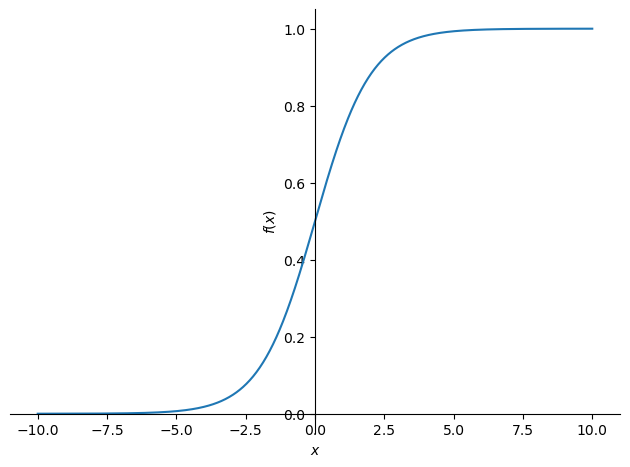

In [39]:
import sympy as sp

x = sp.symbols('x')
expr = 1 / (1 + sp.exp(-x))
sp.plot(expr, (x,-10,10))

In [40]:
def calc_preds(coeffs, indeps): return torch.sigmoid((indeps * coeffs).sum(axis=1))

In [41]:
fin_coeffs = train_model(30, lr=1)

loss = 0.575; loss = 0.559; loss = 0.524; loss = 0.466; loss = 0.394; loss = 0.336; loss = 0.303; loss = 0.286; loss = 0.275; loss = 0.264; loss = 0.253; loss = 0.241; loss = 0.228; loss = 0.217; loss = 0.208; loss = 0.202; loss = 0.197; loss = 0.194; loss = 0.193; loss = 0.191; loss = 0.191; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; 

In [42]:
acc(fin_coeffs)

tensor(0.8000)

In [43]:
get_coeffs(fin_coeffs)

{'Age': tensor(-0.5186),
 'SibSp': tensor(-0.3550),
 'Parch': tensor(-0.0026),
 'LogFare': tensor(1.5156),
 'Sex_female': tensor(12.0612),
 'Sex_male': tensor(-14.4650),
 'Pclass_1': tensor(4.3721),
 'Pclass_2': tensor(2.9558),
 'Pclass_3': tensor(-9.2319),
 'Embarked_C': tensor(2.1195),
 'Embarked_Q': tensor(0.5339),
 'Embarked_S': tensor(-4.8872)}

# Submit to Kaggle

In [44]:
current_session = Path(locals()['__session__']).parent

test_df = pd.read_csv(current_session / "test.csv")

In [45]:
test_df.describe(include='all')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [46]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [47]:
test_df['Fare']=test_df.Fare.fillna(0)

In [48]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [49]:
modes = test_df.mode().iloc[0]
modes

PassengerId                              892
Pclass                                   3.0
Name           Abbott, Master. Eugene Joseph
Sex                                     male
Age                                     21.0
SibSp                                    0.0
Parch                                    0.0
Ticket                              PC 17608
Fare                                    7.75
Cabin                        B57 B59 B63 B66
Embarked                                   S
Name: 0, dtype: object

In [50]:
test_df = test_df.fillna(modes)
test_df['LogFare'] = np.log(test_df.Fare + 1)

In [51]:
test_df = pd.get_dummies(test_df, columns=['Sex', 'Pclass', 'Embarked'], dtype=int)


In [52]:
tst_indep = tensor(test_df[X.columns].values, dtype=torch.float)
tst_indep = tst_indep / vals

In [53]:
test_df['Survived'] = (calc_preds(tst_indep, fin_coeffs)> 0.5).int()

In [54]:
sub_df = test_df[['PassengerId', 'Survived']]
sub_df.to_csv('sub.csv', index=False)

In [55]:
!head 'sub.csv'

PassengerId,Survived
892,0
893,0
894,0
895,0
896,0
897,0
898,1
899,0
900,1


# Using Matrix Product

In [56]:
display(tst_indep.shape)
display(coeffs.shape)
display((tst_indep * coeffs).shape)
display((tst_indep * coeffs).sum(axis=1).shape)

# (tst_indep * coeffs).sum(axis=1)

torch.Size([418, 12])

torch.Size([12])

torch.Size([418, 12])

torch.Size([418])

In [57]:
# float vs double precision issue -> sum is not associative for float numbers -> order matters due to rounding errors
# use double for higher precision

# torch.isclose((tst_indep.double() * coeffs.double()).sum(axis=1), 
#               tst_indep.double()@coeffs.double(), rtol=1e-09, atol=1e-09)

In [58]:
calc_loss(init_coeffs(), trn_indep, trn_dep)
# calc_preds(init_coeffs(), trn_indep)
# torch.abs(t_dep-calc_preds(init_coeffs(), t_indep))

tensor(0.5745, grad_fn=<MeanBackward0>)

In [59]:
def calc_preds(coeffs, indeps): return torch.sigmoid(indeps@coeffs)
def init_coeffs():
    torch.manual_seed(42)
    return (torch.rand(n_coeff,1)-0.5).requires_grad_()

In [60]:
trn_dep = trn_dep[:,None]
val_dep = val_dep[:,None]

In [61]:
# init_coeffs()

In [62]:
init_coeffs().shape

torch.Size([12, 1])

In [63]:
t_indep.shape

torch.Size([891, 12])

In [64]:
calc_preds(init_coeffs(), t_indep).shape

torch.Size([891, 1])

In [65]:
calc_loss(init_coeffs(), trn_indep, trn_dep)
# calc_preds(init_coeffs(), trn_indep)
# torch.abs(t_dep-calc_preds(init_coeffs(), t_indep))

tensor(0.5745, grad_fn=<MeanBackward0>)

In [66]:
coeffs = train_model(30, lr=1)

loss = 0.575; loss = 0.559; loss = 0.524; loss = 0.466; loss = 0.394; loss = 0.336; loss = 0.303; loss = 0.286; loss = 0.275; loss = 0.264; loss = 0.253; loss = 0.241; loss = 0.228; loss = 0.217; loss = 0.208; loss = 0.202; loss = 0.197; loss = 0.194; loss = 0.193; loss = 0.191; loss = 0.191; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; loss = 0.190; 

In [67]:
acc(coeffs)

tensor(0.8000)

In [68]:
coeffs.shape

torch.Size([12, 1])

# Neural network

In [69]:
def init_coeffs(n_hidden=20):
    torch.manual_seed(42)
    layer1 = (torch.rand(n_coeff,n_hidden)-0.5) / n_hidden
    layer2 = (torch.rand(n_hidden,1)-0.3)
    const = torch.rand(1)[0]
    return layer1.requires_grad_(), layer2.requires_grad_(), const.requires_grad_()

In [70]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    l1,l2,const = coeffs
    res = F.relu(indeps@l1)
    res = res@l2 + const
    return torch.sigmoid(res)

In [71]:
def update_coeffs(coeffs, lr): 
    for layer in coeffs: layer.sub_(layer.grad * lr)

In [72]:
coeffs = train_model(lr=0.8)

loss = 0.552; loss = 0.548; loss = 0.541; loss = 0.530; loss = 0.512; loss = 0.483; loss = 0.442; loss = 0.390; loss = 0.339; loss = 0.306; loss = 0.283; loss = 0.252; loss = 0.217; loss = 0.203; loss = 0.206; loss = 0.211; loss = 0.214; loss = 0.216; loss = 0.217; loss = 0.217; loss = 0.217; loss = 0.218; loss = 0.218; loss = 0.218; loss = 0.218; loss = 0.218; loss = 0.218; loss = 0.218; loss = 0.217; loss = 0.216; 

In [73]:
acc(coeffs)

tensor(0.8000)

# Deep Learning

In [74]:
def init_coeffs():
    hiddens = [10,10] # size of each hidden layer
    sizes = [n_coeff] + hiddens + [1]
    n = len(sizes)
    layers = [(torch.rand(sizes[i],sizes[i+1])-0.5)/(sizes[i+1]*n) for i in range(n-1)]
    consts = [(torch.rand(1)[0]-0.5)*0.1 for i in range(n-1)]
    for l in layers+consts: l.requires_grad_()
    return layers, consts

In [75]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    layers,consts = coeffs
    n = len(layers)
    res = indeps

    for i,l in enumerate(layers):
        res = res@l + consts[i]
        if i != n-1: res = F.relu(res)
    return torch.sigmoid(res)

In [76]:
def update_coeffs(coeffs, lr):
    layers, consts = coeffs
    for layer in layers+consts: layer.sub_(layer.grad * lr)

In [77]:
coeffs = train_model(lr=0.4)

loss = 0.500; loss = 0.498; loss = 0.495; loss = 0.490; loss = 0.484; loss = 0.476; loss = 0.467; loss = 0.457; loss = 0.446; loss = 0.435; loss = 0.424; loss = 0.415; loss = 0.406; loss = 0.399; loss = 0.393; loss = 0.388; loss = 0.384; loss = 0.381; loss = 0.379; loss = 0.377; loss = 0.376; loss = 0.375; loss = 0.374; loss = 0.374; loss = 0.373; loss = 0.373; loss = 0.373; loss = 0.373; loss = 0.373; loss = 0.373; 

In [78]:
acc(coeffs)

tensor(0.5932)